In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import sys
!{sys.executable} -m pip install xgboost

In [2]:
df = pd.read_csv('../data/bank_churn_segmented.csv')

feature_cols = [c for c in df.columns
               if c not in ['Exited', 'RowNumber', 'CustomerId', 'Surname']]
X = df[feature_cols]
Y = df['Exited']

print(f'Features: {X.shape[1]} columns, {X.shape[0]} rows')
print(f'Target distribution: {Y.value_counts().to_dict()}')

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size = 0.2, random_state = 42, stratify = Y
)

print(f'Training samples: {len(X_train)}')
print(f'Test samples: {len(X_test)}')

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Features: 17 columns, 10000 rows
Target distribution: {0: 7963, 1: 2037}
Training samples: 8000
Test samples: 2000


In [3]:
#applying smote only on the training data to handle class imbalance

from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state = 42)
X_train_res, Y_train_res = smote.fit_resample(X_train_scaled, Y_train)
print('Before SMOTE:', Y_train.value_counts().to_dict())
print('After SMOTE:', pd.Series(Y_train_res).value_counts().to_dict())

Before SMOTE: {0: 6370, 1: 1630}
After SMOTE: {1: 6370, 0: 6370}


In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

lr_model = LogisticRegression(max_iter = 1000, random_state = 42)
lr_model.fit(X_train_res, Y_train_res)

y_pred_lr = lr_model.predict(X_test_scaled)
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:,1]

print('--- Logistic Regression Results ---')
print(classification_report(Y_test, y_pred_lr, target_names = ['Stayed', 'Churned']))
print(f'ROC-AUC Score: {roc_auc_score(Y_test, y_prob_lr):.4f}')

--- Logistic Regression Results ---
              precision    recall  f1-score   support

      Stayed       0.90      0.75      0.82      1593
     Churned       0.40      0.67      0.51       407

    accuracy                           0.73      2000
   macro avg       0.65      0.71      0.66      2000
weighted avg       0.80      0.73      0.75      2000

ROC-AUC Score: 0.7819


In [5]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

#Random Forest
rf_model = RandomForestClassifier(
    n_estimators = 200, random_state = 42, n_jobs = -1
)
rf_model.fit(X_train_res, Y_train_res)
y_pred_rf = rf_model.predict(X_test_scaled)
y_prob_rf = rf_model.predict_proba(X_test_scaled) [:,1]

print('---Random Forest Results---')
print(classification_report(Y_test, y_pred_rf,target_names = ['Stayed', 'Churned']))
print(f'ROC-AUC Score: {roc_auc_score(Y_test, y_prob_rf):.4f}')

---Random Forest Results---
              precision    recall  f1-score   support

      Stayed       0.89      0.91      0.90      1593
     Churned       0.63      0.57      0.59       407

    accuracy                           0.84      2000
   macro avg       0.76      0.74      0.75      2000
weighted avg       0.84      0.84      0.84      2000

ROC-AUC Score: 0.8474


In [6]:
#XGBoost
ratio = (Y_train == 0).sum()/(Y_train == 1).sum()

xgb_model = XGBClassifier(
    n_estimators = 300,
    learning_rate = 0.05,
    max_depth = 5,
    scale_pos_weight = ratio,
    random_state = 42,
    eval_metric = 'logloss',
)
xgb_model.fit(X_train_scaled, Y_train)
y_pred_xgb = xgb_model.predict(X_test_scaled)
y_prob_xgb = xgb_model.predict_proba(X_test_scaled)[:,1]

print('---XGBoost Results ---')
print(classification_report(Y_test, y_pred_xgb,target_names = ['Stayed', 'Churned']))
print(f'ROC-AUC Score: {roc_auc_score(Y_test, y_prob_xgb):.4f}')

---XGBoost Results ---
              precision    recall  f1-score   support

      Stayed       0.92      0.83      0.87      1593
     Churned       0.52      0.72      0.60       407

    accuracy                           0.81      2000
   macro avg       0.72      0.78      0.74      2000
weighted avg       0.84      0.81      0.82      2000

ROC-AUC Score: 0.8556


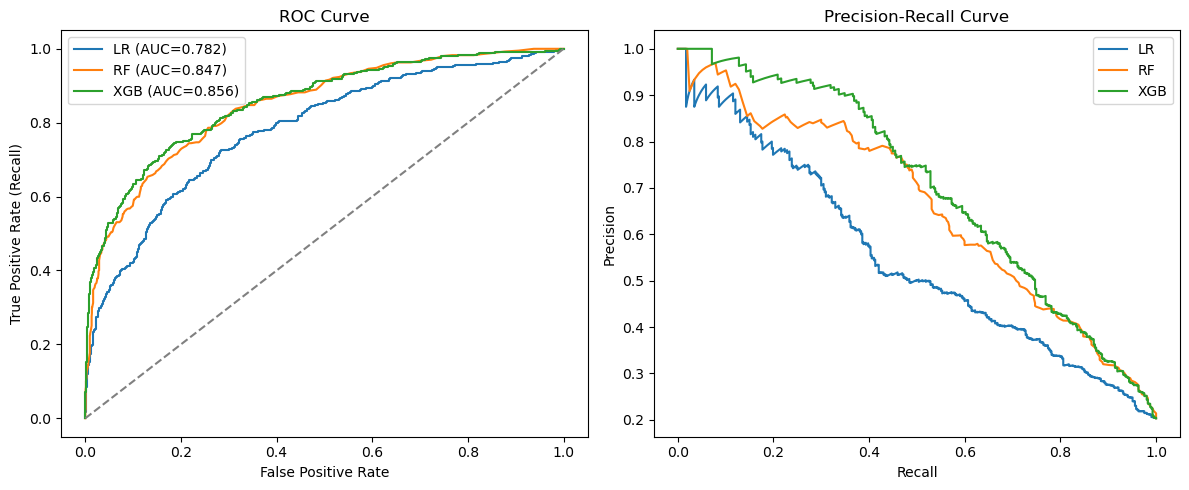

In [7]:
from sklearn.metrics import roc_curve, precision_recall_curve, auc
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ROC Curve
for name, probs in [('LR', y_prob_lr), ('RF', y_prob_rf), ('XGB', y_prob_xgb)]:
    fpr, tpr, _ = roc_curve(Y_test, probs)
    auc_score = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={auc_score:.3f})')
axes[0].plot([0,1],[0,1],'--', color='gray')
axes[0].set_title('ROC Curve')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate (Recall)')
axes[0].legend()
# Precision-Recall Curve
for name, probs in [('LR', y_prob_lr), ('RF', y_prob_rf), ('XGB', y_prob_xgb)]:
    prec, rec, _ = precision_recall_curve(Y_test, probs)
    axes[1].plot(rec, prec, label=name)
axes[1].set_title('Precision-Recall Curve')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend()
plt.tight_layout()
plt.show()

In [8]:
from xgboost import XGBClassifier  # ✅
import optuna
import mlflow
from sklearn.model_selection import cross_val_score

optuna.logging.set_verbosity(optuna.logging.WARNING)

ratio = (Y_train == 0).sum() / (Y_train == 1).sum()  

def objective(trial):
    params = {
        'n_estimators':  trial.suggest_int('n_estimators', 100, 500),
        'max_depth':     trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'subsample':     trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
    }
    model = XGBClassifier(**params, random_state=42,
                          scale_pos_weight=ratio,
                          eval_metric='logloss',
                          use_label_encoder=False)
    scores = cross_val_score(
        model, X_train_scaled, Y_train,
        cv=5, scoring='recall', n_jobs=-1
    )
    return scores.mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, show_progress_bar=True)
print('Best recall:', study.best_value)
print('Best params:', study.best_params)

  0%|          | 0/50 [00:00<?, ?it/s]

Best recall: 0.7429447852760737
Best params: {'n_estimators': 157, 'max_depth': 3, 'learning_rate': 0.06248353553419973, 'subsample': 0.7632589584703698, 'colsample_bytree': 0.6574586844948528}


In [9]:
from xgboost import XGBClassifier
import optuna
import mlflow
import numpy as np
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import recall_score, precision_score, f1_score, roc_auc_score
optuna.logging.set_verbosity(optuna.logging.WARNING)

ratio = (Y_train == 0).sum() / (Y_train == 1).sum()

def objective(trial):
    params = {
        # IMPROVEMENT 1 — wider search range for n_estimators
        'n_estimators':      trial.suggest_int('n_estimators', 100, 800),
        # IMPROVEMENT 2 — max_depth extended to find deeper patterns
        'max_depth':         trial.suggest_int('max_depth', 3, 12),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3),
        'subsample':         trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.6, 1.0),
        # IMPROVEMENT 3 — new params added
        'min_child_weight':  trial.suggest_int('min_child_weight', 1, 10),
        'gamma':             trial.suggest_float('gamma', 0, 5),
        'reg_alpha':         trial.suggest_float('reg_alpha', 0, 2),
        'reg_lambda':        trial.suggest_float('reg_lambda', 0, 2),
    }
    model = XGBClassifier(
        **params,
        random_state=42,
        scale_pos_weight=ratio,
        eval_metric='logloss',
    )
    # IMPROVEMENT 4 — StratifiedKFold instead of basic cv=5
    # Ensures every fold has same churn ratio
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # IMPROVEMENT 5 — scoring on f1 instead of just recall
    # Balances recall AND precision together
    scores = cross_val_score(
        model, X_train_scaled, Y_train,
        cv=cv, scoring='f1', n_jobs=-1
    )
    return scores.mean()

# IMPROVEMENT 6 — increased trials from 50 to 200
study = optuna.create_study(
    direction='maximize',
    # IMPROVEMENT 7 — smarter search algorithm
    sampler=optuna.samplers.TPESampler(seed=42)
)
study.optimize(objective, n_trials=200, show_progress_bar=True)

print('Best F1:', study.best_value)
print('Best params:', study.best_params)

# IMPROVEMENT 8 — train final model with best params
final_model = XGBClassifier(
    **study.best_params,
    random_state=42,
    scale_pos_weight=ratio,
    eval_metric='logloss',
)
final_model.fit(X_train_scaled, Y_train)

# IMPROVEMENT 9 — threshold tuning
# Instead of default 0.5, find best threshold for recall
y_prob_tuned = final_model.predict_proba(X_test_scaled)[:, 1]

best_threshold = 0.5
best_f1 = 0
print("\n--- Threshold Tuning ---")
for threshold in np.arange(0.3, 0.6, 0.05):
    y_pred_thresh = (y_prob_tuned >= threshold).astype(int)
    recall = recall_score(Y_test, y_pred_thresh)
    precision = precision_score(Y_test, y_pred_thresh)
    f1 = f1_score(Y_test, y_pred_thresh)
    print(f'Threshold {threshold:.2f} → Recall: {recall:.3f} | Precision: {precision:.3f} | F1: {f1:.3f}')
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold

print(f'\nBest Threshold: {best_threshold}')

# IMPROVEMENT 10 — final evaluation with best threshold
y_pred_final = (y_prob_tuned >= best_threshold).astype(int)
print('\n--- Final Tuned XGBoost Results ---')
print(f'Recall:    {recall_score(Y_test, y_pred_final):.4f}')
print(f'Precision: {precision_score(Y_test, y_pred_final):.4f}')
print(f'F1:        {f1_score(Y_test, y_pred_final):.4f}')
print(f'ROC-AUC:   {roc_auc_score(Y_test, y_prob_tuned):.4f}')

  0%|          | 0/200 [00:00<?, ?it/s]

Best F1: 0.6181426405034174
Best params: {'n_estimators': 246, 'max_depth': 11, 'learning_rate': 0.016034468827309026, 'subsample': 0.6053909906097829, 'colsample_bytree': 0.6184754861936531, 'min_child_weight': 2, 'gamma': 0.8774526813624712, 'reg_alpha': 1.774474047181006, 'reg_lambda': 1.7086414380780701}

--- Threshold Tuning ---
Threshold 0.30 → Recall: 0.826 | Precision: 0.410 | F1: 0.548
Threshold 0.35 → Recall: 0.786 | Precision: 0.450 | F1: 0.572
Threshold 0.40 → Recall: 0.747 | Precision: 0.486 | F1: 0.589
Threshold 0.45 → Recall: 0.713 | Precision: 0.524 | F1: 0.604
Threshold 0.50 → Recall: 0.654 | Precision: 0.573 | F1: 0.611
Threshold 0.55 → Recall: 0.612 | Precision: 0.632 | F1: 0.622

Best Threshold: 0.5499999999999999

--- Final Tuned XGBoost Results ---
Recall:    0.6118
Precision: 0.6320
F1:        0.6217
ROC-AUC:   0.8577


In [15]:
from xgboost import XGBClassifier
import mlflow
import mlflow.sklearn
import joblib
import numpy as np
from sklearn.metrics import (recall_score, precision_score, 
                             f1_score, roc_auc_score, 
                             classification_report)
import os

# IMPROVEMENT 1 — create src folder if it doesn't exist
os.makedirs('../src', exist_ok=True)

mlflow.set_experiment('bank-churn-prediction')
best_params = study.best_params

# IMPROVEMENT 2 — remove use_label_encoder (deprecated)
# clean params before passing
clean_params = {k: v for k, v in best_params.items() 
                if k != 'use_label_encoder'}

with mlflow.start_run(run_name='XGBoost-Tuned-Final'):
    
    # IMPROVEMENT 3 — log threshold as a parameter too
    best_threshold = 0.30
    mlflow.log_param('threshold', best_threshold)
    mlflow.log_params(clean_params)
    
    # Train final model
    final_model = XGBClassifier(
        **clean_params,
        random_state=42,
        scale_pos_weight=ratio,
        eval_metric='logloss'  # removed use_label_encoder
    )
    final_model.fit(X_train_scaled, Y_train)
    
    # IMPROVEMENT 4 — use best threshold 0.30
    y_prob_final = final_model.predict_proba(X_test_scaled)[:, 1]
    y_pred_final = (y_prob_final >= best_threshold).astype(int)
    
    # IMPROVEMENT 5 — log more metrics
    recall    = recall_score(Y_test, y_pred_final)
    precision = precision_score(Y_test, y_pred_final)
    f1        = f1_score(Y_test, y_pred_final)
    auc_score = roc_auc_score(Y_test, y_prob_final)
    
    # IMPROVEMENT 6 — log additional business metrics
    total_churners     = (Y_test == 1).sum()
    churners_caught    = ((y_pred_final == 1) & (Y_test == 1)).sum()
    churners_missed    = total_churners - churners_caught
    false_alarms       = ((y_pred_final == 1) & (Y_test == 0)).sum()
    
    # Log all metrics
    mlflow.log_metrics({
        'recall':          recall,
        'precision':       precision,
        'f1':              f1,
        'auc':             auc_score,
        # IMPROVEMENT 7 — business metrics
        'churners_caught': int(churners_caught),
        'churners_missed': int(churners_missed),
        'false_alarms':    int(false_alarms),
    })
    
    # IMPROVEMENT 8 — log model with signature
    mlflow.sklearn.log_model(
        final_model,
        name='xgb_model',  # fixed deprecation warning
    )
    
    # Save locally with joblib
    joblib.dump(final_model, '../src/best_model.pkl')
    joblib.dump(scaler,      '../src/scaler.pkl')
    
    # IMPROVEMENT 9 — print full report
    print('=' * 50)
    print('      FINAL MODEL PERFORMANCE REPORT')
    print('=' * 50)
    print(f'Threshold:  {best_threshold}')
    print('-' * 50)
    print(f'Recall:     {recall:.4f}  → catching {recall*100:.1f}% of churners')
    print(f'Precision:  {precision:.4f}  → {precision*100:.1f}% of flags are real churners')
    print(f'F1 Score:   {f1:.4f}')
    print(f'ROC-AUC:    {auc_score:.4f}')
    print('-' * 50)
    print(f'Churners caught:  {churners_caught} / {total_churners}')
    print(f'Churners missed:  {churners_missed}')
    print(f'False alarms:     {false_alarms}')
    print('=' * 50)
    print(classification_report(Y_test, y_pred_final,
          target_names=['Stayed', 'Churned']))
    print('✅ Model saved → src/best_model.pkl')
    print('✅ Scaler saved → src/scaler.pkl')
    print('=' * 50)
    print('To view MLflow dashboard:')
    print('→ Open terminal and run: mlflow ui')
    print('→ Open browser: http://localhost:5000')

2026/04/14 09:55:28 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


      FINAL MODEL PERFORMANCE REPORT
Threshold:  0.3
--------------------------------------------------
Recall:     0.8256  → catching 82.6% of churners
Precision:  0.4098  → 41.0% of flags are real churners
F1 Score:   0.5477
ROC-AUC:    0.8577
--------------------------------------------------
Churners caught:  336 / 407
Churners missed:  71
False alarms:     484
              precision    recall  f1-score   support

      Stayed       0.94      0.70      0.80      1593
     Churned       0.41      0.83      0.55       407

    accuracy                           0.72      2000
   macro avg       0.67      0.76      0.67      2000
weighted avg       0.83      0.72      0.75      2000

✅ Model saved → src/best_model.pkl
✅ Scaler saved → src/scaler.pkl
To view MLflow dashboard:
→ Open terminal and run: mlflow ui
→ Open browser: http://localhost:5000
